In [1]:
import matplotlib.pyplot as plt
from src.data_loader import load_binance_data_csv
from src.features import build_features, FEATURE_COLUMNS, add_returns, add_moving_averages
from src.validation import chronological_split, random_strategy_baseline, significance
from src.models import make_logreg, make_gradient_boosting, train_and_predict, arima_signal, fit_garch_volatility
from src.backtest import run_ml_strategy, run_ma_strategy, run_agent_strategy
from src.metrics import summary
from src.agents import TradingAgent

import pandas as pd

In [2]:
df = load_binance_data_csv()

# 2. Features
df = add_returns(df)
df = add_moving_averages(df, fast=50, slow=200)

df = run_ma_strategy(df, fee=0.001)

metrics = pd.DataFrame({
    "MA50/200":   summary(df["strategy_equity"], df["strategy_return"]),
    "Buy & Hold": summary(df["market_equity"],  df["market_return"]),
})
metrics

,MA50/200,Buy & Hold
ROI %,86.13,64.71
Sharpe,0.58,0.48
Sortino,0.66,0.68
Calmar,0.41,0.18
Max Drawdown %,-37.25,-66.73
Win Rate %,26.23,49.41


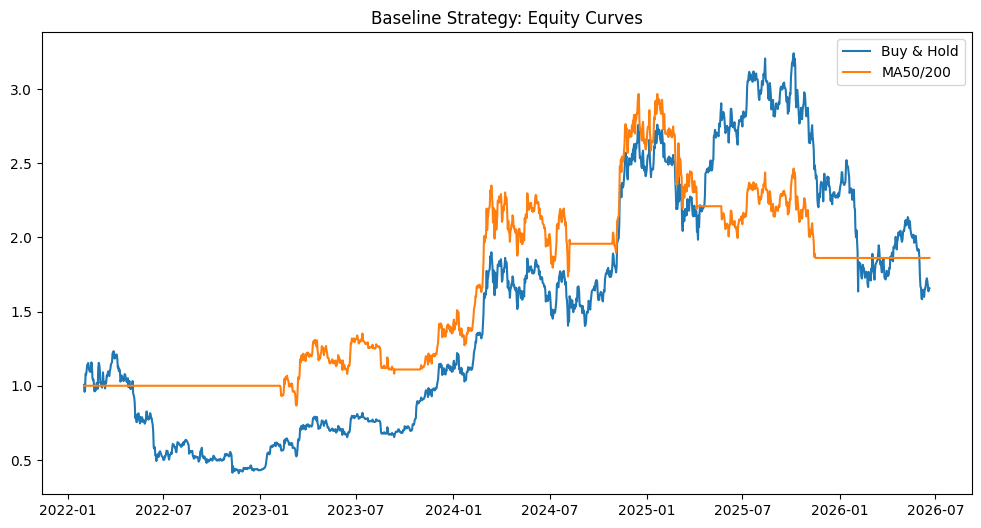

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df["timestamp"], df["market_equity"], label="Buy & Hold")
plt.plot(df["timestamp"], df["strategy_equity"], label="MA50/200")
plt.legend()
plt.title("Baseline Strategy: Equity Curves")
plt.show()

In [4]:
# 1. Данные + признаки
df = load_binance_data_csv()
df = build_features(df)

# 2. Хронологический split (без перемешивания!)
train, test = chronological_split(df, train_ratio=0.7)

# 3. Логистическая регрессия (бенчмарк)
test_lr, _ = train_and_predict(make_logreg(), train, test, FEATURE_COLUMNS)
bt_lr = run_ml_strategy(test_lr)

# 4. Градиентный бустинг
test_gb, _ = train_and_predict(make_gradient_boosting(), train, test, FEATURE_COLUMNS)
bt_gb = run_ml_strategy(test_gb)

# 5. Сравнительная таблица (на ОДНОМ тестовом периоде)
results = pd.DataFrame({
    "LogReg":           summary(bt_lr["strategy_equity"], bt_lr["strategy_return"]),
    "GradBoosting":     summary(bt_gb["strategy_equity"], bt_gb["strategy_return"]),
    "Buy & Hold (test)": summary(bt_gb["market_equity"], bt_gb["market_return"]),
})
results

,LogReg,GradBoosting,Buy & Hold (test)
ROI %,-25.93,-61.11,-24.76
Sharpe,-0.53,-2.02,-0.34
Sortino,-0.49,-2.09,-0.48
Calmar,-0.42,-0.74,-0.38
Max Drawdown %,-48.62,-69.11,-51.16
Win Rate %,18.58,17.75,49.27


In [5]:
strat_roi = (bt_gb["strategy_equity"].iloc[-1] - 1) * 100
random_rois = random_strategy_baseline(bt_gb)
pct, pval = significance(strat_roi, random_rois)
print(f"Стратегия обогнала {pct:.1f}% случайных стратегий (p-value ≈ {pval:.3f})")

Стратегия обогнала 2.2% случайных стратегий (p-value ≈ 0.978)


In [6]:
print("Доля 'вверх' в train target:", train["target"].mean().round(3))
print("Доля 'вверх' в test target:", test["target"].mean().round(3))
print("Доля предсказаний '1' (LogReg):", test_lr["pred"].mean().round(3))
print("Доля предсказаний '1' (GB):", test_gb["pred"].mean().round(3))

Доля 'вверх' в train target: 0.494
Доля 'вверх' в test target: 0.493
Доля предсказаний '1' (LogReg): 0.399
Доля предсказаний '1' (GB): 0.437


<Axes: title={'center': 'Feature Importance (GB)'}>

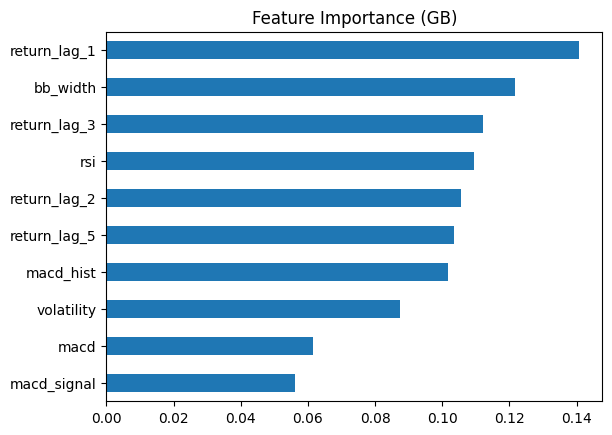

In [7]:
_, gb_model = train_and_predict(make_gradient_boosting(), train, test, FEATURE_COLUMNS)
importances = pd.Series(gb_model.feature_importances_, index=FEATURE_COLUMNS)
importances.sort_values().plot(kind="barh", title="Feature Importance (GB)")

In [8]:
test_arima = test.copy()
test_arima["pred"] = arima_signal(train["market_return"], test["market_return"])
bt_arima = run_ml_strategy(test_arima)   # тот же бэктест-движок -> сравнимо

results["ARIMA"] = summary(bt_arima["strategy_equity"], bt_arima["strategy_return"])
results

C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\pda95\PycharmProjects\ai-crypto-hedge-fund\.venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Like

,LogReg,GradBoosting,Buy & Hold (test),ARIMA
ROI %,-25.93,-61.11,-24.76,-33.23
Sharpe,-0.53,-2.02,-0.34,-0.50
Sortino,-0.49,-2.09,-0.48,-0.66
Calmar,-0.42,-0.74,-0.38,-0.48
Max Drawdown %,-48.62,-69.11,-51.16,-55.07
Win Rate %,18.58,17.75,49.27,44.05


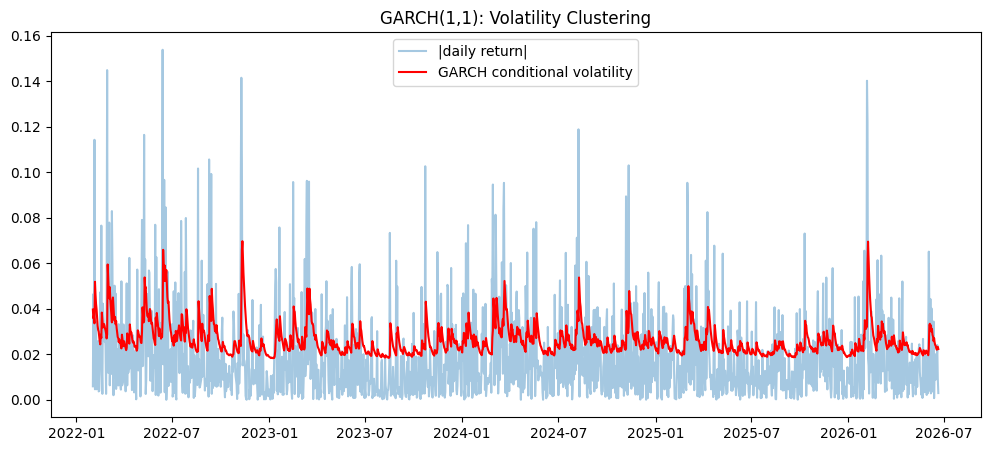

                     Constant Mean - GARCH Model Results                      
Dep. Variable:          market_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3774.73
Distribution:                  Normal   AIC:                           7557.46
Method:            Maximum Likelihood   BIC:                           7578.97
                                        No. Observations:                 1601
Date:                Mon, Jun 22 2026   Df Residuals:                     1600
Time:                        11:54:54   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1288  5.812e-02      2.216  2.667e-02 [1.490e-0

In [9]:
fitted, cond_vol = fit_garch_volatility(df["market_return"])

plt.figure(figsize=(12, 5))
plt.plot(df["timestamp"], df["market_return"].abs(), alpha=0.4, label="|daily return|")
plt.plot(df["timestamp"], cond_vol, color="red", label="GARCH conditional volatility")
plt.legend(); plt.title("GARCH(1,1): Volatility Clustering"); plt.show()

print(fitted.summary())

In [10]:
agent = TradingAgent(target_vol=0.02, max_leverage=1.0)
test_agent = agent.decide(test_gb)        # берём датафрейм с pred и volatility
bt_agent = run_agent_strategy(test_agent)

results["Agent"] = summary(bt_agent["strategy_equity"], bt_agent["strategy_return"])
results

,LogReg,GradBoosting,Buy & Hold (test),ARIMA,Agent
ROI %,-25.93,-61.11,-24.76,-33.23,-34.04
Sharpe,-0.53,-2.02,-0.34,-0.50,-1.75
Sortino,-0.49,-2.09,-0.48,-0.66,-1.26
Calmar,-0.42,-0.74,-0.38,-0.48,-0.65
Max Drawdown %,-48.62,-69.11,-51.16,-55.07,-41.51
Win Rate %,18.58,17.75,49.27,44.05,8.35


In [11]:
bt_ma = run_ma_strategy(df, fee=0.001)

In [12]:
final = pd.DataFrame({
    "Baseline MA":  summary(bt_ma["strategy_equity"], bt_ma["strategy_return"]),
    "ARIMA":        summary(bt_arima["strategy_equity"], bt_arima["strategy_return"]),  # эконометрика
    "LogReg":       summary(bt_lr["strategy_equity"], bt_lr["strategy_return"]),        # ML
    "GradBoosting": summary(bt_gb["strategy_equity"], bt_gb["strategy_return"]),        # ML
    "AI Agent":     summary(bt_agent["strategy_equity"], bt_agent["strategy_return"]),  # агент
    "Buy & Hold":   summary(bt_gb["market_equity"], bt_gb["market_return"]),
})
final

,Baseline MA,ARIMA,LogReg,GradBoosting,AI Agent,Buy & Hold
ROI %,86.13,-33.23,-25.93,-61.11,-34.04,-24.76
Sharpe,0.58,-0.50,-0.53,-2.02,-1.75,-0.34
Sortino,0.66,-0.66,-0.49,-2.09,-1.26,-0.48
Calmar,0.41,-0.48,-0.42,-0.74,-0.65,-0.38
Max Drawdown %,-37.25,-55.07,-48.62,-69.11,-41.51,-51.16
Win Rate %,26.27,44.05,18.58,17.75,8.35,49.27


In [13]:
from src.backtest import run_ma_rsi_strategy

bt_ma_rsi = run_ma_rsi_strategy(df)

results["MA + RSI filter"] = summary(bt_ma_rsi["strategy_equity"], bt_ma_rsi["strategy_return"])
results

,LogReg,GradBoosting,Buy & Hold (test),ARIMA,Agent,MA + RSI filter
ROI %,-25.93,-61.11,-24.76,-33.23,-34.04,196.58
Sharpe,-0.53,-2.02,-0.34,-0.50,-1.75,0.97
Sortino,-0.49,-2.09,-0.48,-0.66,-1.26,1.02
Calmar,-0.42,-0.74,-0.38,-0.48,-0.65,1.30
Max Drawdown %,-48.62,-69.11,-51.16,-55.07,-41.51,-21.66
Win Rate %,18.58,17.75,49.27,44.05,8.35,19.76


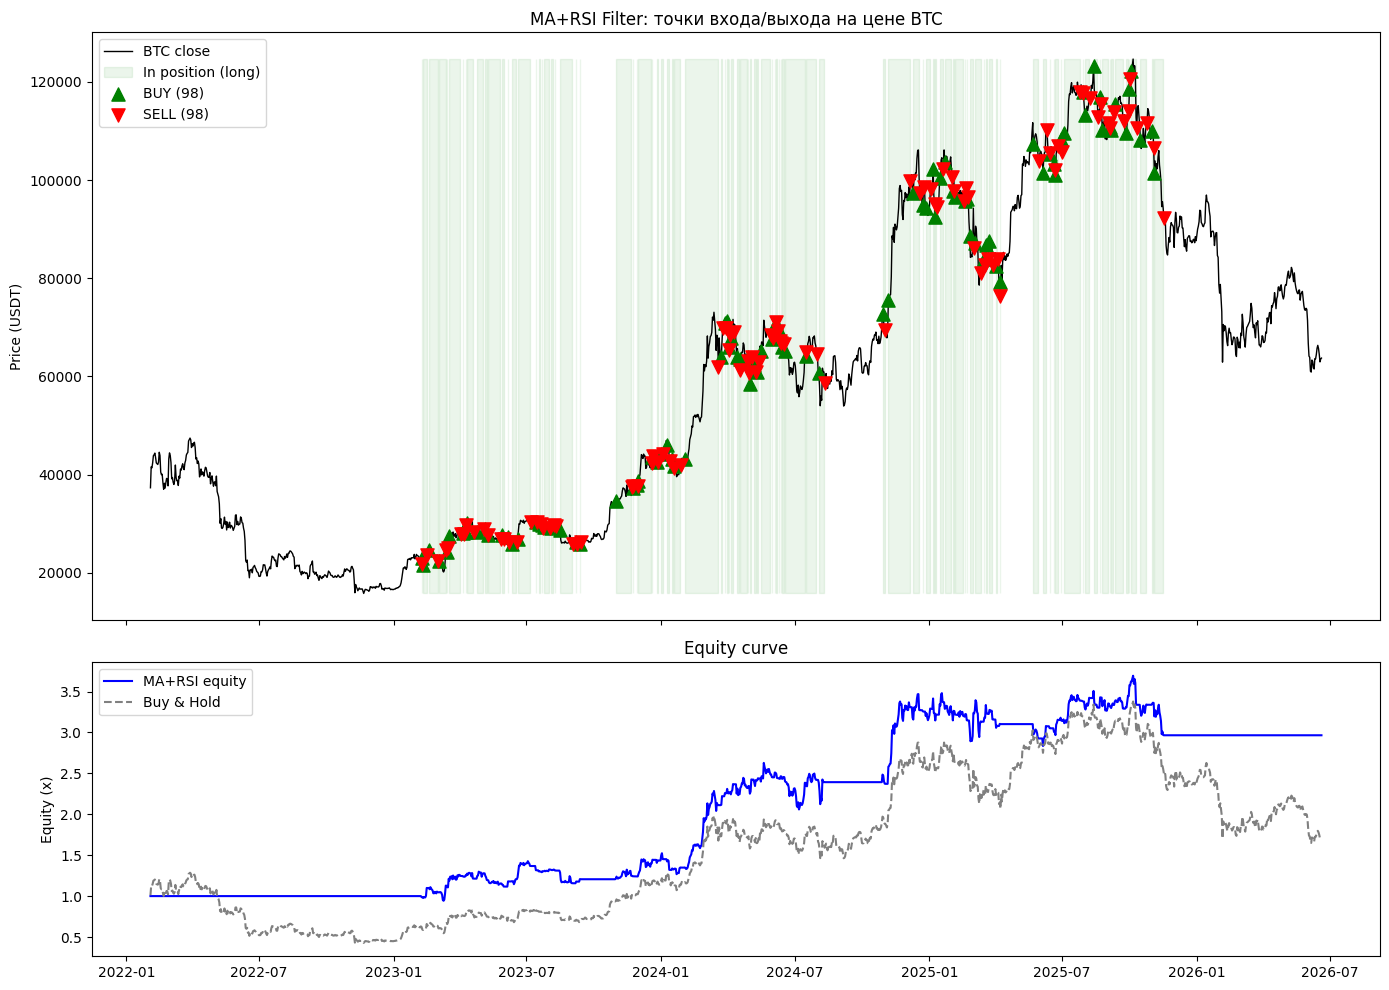

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# bt_ma_rsi — это результат run_ma_rsi_strategy(df) на ТОМ ЖЕ периоде, что и таблица.
# Должен содержать: timestamp, close, position, strategy_equity, market_equity
bt = bt_ma_rsi.copy()

# --- Находим моменты входа (0 -> 1) и выхода (1 -> 0) ---
bt["pos_change"] = bt["position"].diff()
buys  = bt[bt["pos_change"] == 1]   # вход в лонг
sells = bt[bt["pos_change"] == -1]  # выход в кэш

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

# === Верхний график: цена + точки входа/выхода ===
ax1 = axes[0]
ax1.plot(bt["timestamp"], bt["close"], color="black", lw=1, label="BTC close")

# зелёным закрашиваем периоды, когда мы В ПОЗИЦИИ (position == 1)
ax1.fill_between(bt["timestamp"], bt["close"].min(), bt["close"].max(),
                 where=(bt["position"] == 1), color="green", alpha=0.08,
                 label="In position (long)")

ax1.scatter(buys["timestamp"],  buys["close"],  marker="^", color="green",
            s=90, zorder=5, label=f"BUY ({len(buys)})")
ax1.scatter(sells["timestamp"], sells["close"], marker="v", color="red",
            s=90, zorder=5, label=f"SELL ({len(sells)})")

ax1.set_title("MA+RSI Filter: точки входа/выхода на цене BTC")
ax1.set_ylabel("Price (USDT)")
ax1.legend(loc="upper left")

# === Нижний график: equity стратегии vs Buy & Hold ===
ax2 = axes[1]
ax2.plot(bt["timestamp"], bt["strategy_equity"], color="blue", label="MA+RSI equity")
ax2.plot(bt["timestamp"], bt["market_equity"],  color="gray", ls="--", label="Buy & Hold")
ax2.set_title("Equity curve")
ax2.set_ylabel("Equity (x)")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()


In [15]:
print("=== ДИАГНОСТИКА MA+RSI ===\n")

# 1) Сколько времени стратегия реально в рынке?
exposure = (bt["position"] == 1).mean() * 100
print(f"1. Доля времени в позиции (exposure): {exposure:.1f}%")
print(f"   Число входов (BUY):  {len(buys)}")
print(f"   Число выходов (SELL): {len(sells)}")

# 2) Главная проверка на look-ahead:
#    позиция[t] НЕ должна зависеть от доходности[t].
#    position должна быть строго сдвинутой версией signal.
shifted_ok = (bt["position"].iloc[1:].values
              == bt["signal"].shift(1).iloc[1:].values).all()
print(f"\n2. Сигнал сдвинут на 1 бар (нет look-ahead): {shifted_ok}")

# 3) Откуда взялся весь профит? Концентрация в нескольких барах = тревога.
contrib = bt["strategy_return"].sort_values(ascending=False)
top5_share = contrib.head(5).sum() / bt["strategy_return"].sum() * 100
print(f"\n3. Топ-5 баров дали {top5_share:.1f}% всей доходности")
print(f"   Лучшие дневные доходности: {contrib.head(5).round(4).tolist()}")

# 4) Подозрение на нереалистичные дневные доходности (>30% за день = странно)
suspicious = bt[bt["strategy_return"].abs() > 0.30]
print(f"\n4. Баров с |доходностью| > 30% за день: {len(suspicious)}")


=== ДИАГНОСТИКА MA+RSI ===

1. Доля времени в позиции (exposure): 38.0%
   Число входов (BUY):  98
   Число выходов (SELL): 98

2. Сигнал сдвинут на 1 бар (нет look-ahead): True

3. Топ-5 баров дали 39.6% всей доходности
   Лучшие дневные доходности: [0.1188, 0.103, 0.0962, 0.0957, 0.0953]

4. Баров с |доходностью| > 30% за день: 0


In [16]:
from src.validation import chronological_split
from src.features import add_rsi, add_moving_averages
from src.backtest import run_ma_rsi_strategy
from src.metrics import summary
import pandas as pd

train, test = chronological_split(df, train_ratio=0.7)

bt_train = run_ma_rsi_strategy(train)
bt_test  = run_ma_rsi_strategy(test)

compare = pd.DataFrame({
    "MA+RSI (train)": summary(bt_train["strategy_equity"], bt_train["strategy_return"]),
    "MA+RSI (test)":  summary(bt_test["strategy_equity"],  bt_test["strategy_return"]),
})
print(compare)


                MA+RSI (train)  MA+RSI (test)
ROI %                   214.65           1.98
Sharpe                    1.31           0.20
Sortino                   1.48           0.16
Calmar                    2.10           0.08
Max Drawdown %          -21.66         -19.70
Win Rate %               21.20          16.49


              Return %  Volatility %  Sharpe
Max Sharpe         6.6          53.5    0.12
Min Variance     -37.0          42.6   -0.87
Equal Weight     -37.4          60.0   -0.62

Max Sharpe weights:
BTC       0.0
ETH       0.0
BNB     100.0
SOL       0.0
XRP       0.0
ADA       0.0
DOGE      0.0
Name: weight %, dtype: float64


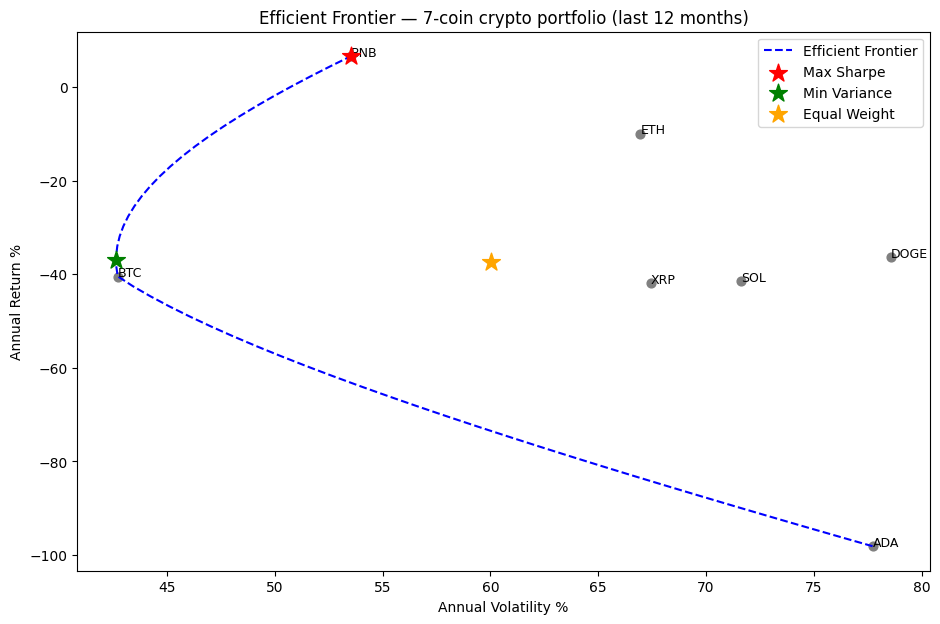

In [17]:
from src.data_loader import load_portfolio_data
from src.portfolio import (
    compute_returns, portfolio_performance,
    optimize_max_sharpe, optimize_min_variance,
    efficient_frontier, weights_table, PERIODS_PER_YEAR,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Данные (только локальный CSV) ---------------------------------
prices = load_portfolio_data()
returns = compute_returns(prices)
mean_returns = returns.mean()
cov_matrix = returns.cov()
assets = list(prices.columns)

# 2. Три портфеля --------------------------------------------------
w_sharpe = optimize_max_sharpe(mean_returns, cov_matrix)
w_minvar = optimize_min_variance(mean_returns, cov_matrix)
w_equal  = np.array([1/len(assets)] * len(assets))

# 3. Сравнительная таблица -----------------------------------------
rows = {}
for name, w in [("Max Sharpe", w_sharpe), ("Min Variance", w_minvar), ("Equal Weight", w_equal)]:
    ret, vol = portfolio_performance(w, mean_returns, cov_matrix)
    rows[name] = {"Return %": round(ret*100, 1),
                  "Volatility %": round(vol*100, 1),
                  "Sharpe": round(ret/vol, 2)}
print(pd.DataFrame(rows).T)

# 4. Веса оптимального портфеля ------------------------------------
print("\nMax Sharpe weights:")
print(weights_table(w_sharpe, assets))

# 5. Эффективная граница + точки портфелей -------------------------
ef = efficient_frontier(mean_returns, cov_matrix)

plt.figure(figsize=(11, 7))
plt.plot(ef[:, 0]*100, ef[:, 1]*100, "b--", label="Efficient Frontier")

for name, w, color in [("Max Sharpe", w_sharpe, "red"),
                       ("Min Variance", w_minvar, "green"),
                       ("Equal Weight", w_equal, "orange")]:
    ret, vol = portfolio_performance(w, mean_returns, cov_matrix)
    plt.scatter(vol*100, ret*100, c=color, s=180, marker="*", label=name, zorder=5)

# отдельные монеты для сравнения
for a in assets:
    r = mean_returns[a]*PERIODS_PER_YEAR*100
    v = np.sqrt(cov_matrix.loc[a, a])*np.sqrt(PERIODS_PER_YEAR)*100
    plt.scatter(v, r, c="gray", s=40)
    plt.annotate(a, (v, r), fontsize=9)

plt.xlabel("Annual Volatility %")
plt.ylabel("Annual Return %")
plt.title("Efficient Frontier — 7-coin crypto portfolio (last 12 months)")
plt.legend()
plt.show()


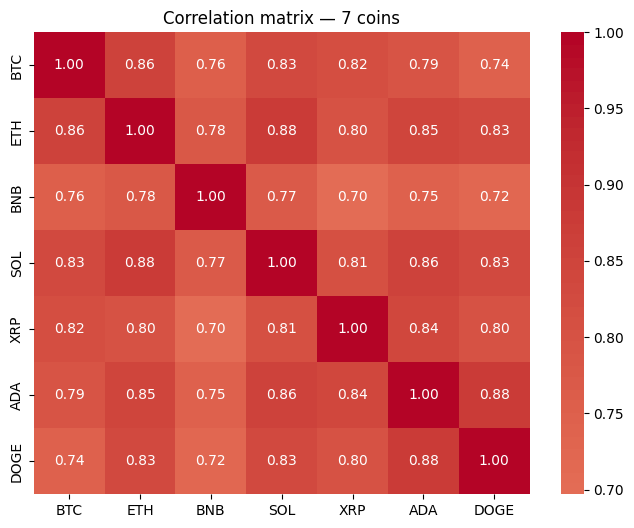

In [18]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix — 7 coins")
plt.show()

In [19]:
split = len(returns) // 2
train_ret = returns.iloc[:split]
test_ret  = returns.iloc[split:]

# веса оптимизируем ТОЛЬКО на train
w_oos = optimize_max_sharpe(train_ret.mean(), train_ret.cov())

# применяем на test (out-of-sample)
oos_daily = (test_ret * w_oos).sum(axis=1)
oos_total = (1 + oos_daily).prod() - 1
print(f"Max Sharpe веса (на train): {dict(zip(assets, (w_oos*100).round(1)))}")
print(f"Out-of-sample доходность на test-периоде: {oos_total*100:.1f}%")


Max Sharpe веса (на train): {'BTC': np.float64(0.0), 'ETH': np.float64(2.6), 'BNB': np.float64(97.4), 'SOL': np.float64(0.0), 'XRP': np.float64(0.0), 'ADA': np.float64(0.0), 'DOGE': np.float64(0.0)}
Out-of-sample доходность на test-периоде: -31.1%
